# Validate DB Dump (Calibration PNGs)

This notebook validates the calibration dump exported from the DB, counts samples per letter, previews a grid, and writes a simple train/val/test split CSV for downstream training.

- Expected PNGs live under either `apps/api/data/db_by_letter` (workspace-local dump) or `data/db_by_letter`.
- Outputs a split file at `apps/api/data/splits/db_dump_splits.csv`.

In [25]:
BASE = "apps/api/data/db_by_letter"

In [26]:
from pathlib import Path
import random
from collections import defaultdict
import matplotlib.pyplot as plt
from PIL import Image

BASE = (Path('..') / 'apps/api/data/db_by_letter').resolve()
assert BASE.exists(), f"Missing directory: {BASE}"
BASE

PosixPath('/mnt/c/Users/PerkD/documents/dev/Daber/apps/api/data/db_by_letter')

In [27]:
# Count samples per letter
counts = {}
letters = sorted([p.name for p in BASE.iterdir() if p.is_dir()])
total = 0
for L in letters:
    n = len([f for f in (BASE / L).glob('*.png')])
    counts[L] = n
    total += n
counts, total


({'א': 8,
  'ב': 5,
  'ג': 6,
  'ד': 5,
  'ה': 9,
  'ו': 6,
  'ז': 4,
  'ח': 6,
  'ט': 6,
  'י': 9,
  'ך': 4,
  'כ': 5,
  'ל': 8,
  'ם': 5,
  'מ': 6,
  'ן': 4,
  'נ': 5,
  'ס': 4,
  'ע': 4,
  'ף': 4,
  'פ': 5,
  'ץ': 5,
  'צ': 5,
  'ק': 4,
  'ר': 8,
  'ש': 5,
  'ת': 6},
 151)

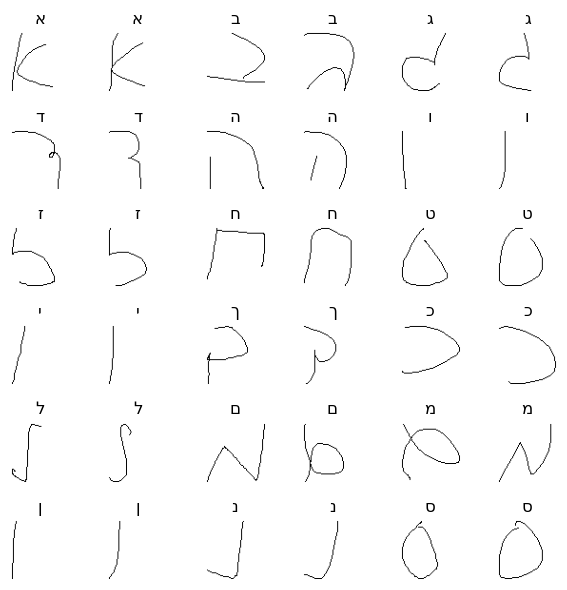

In [28]:
# Visualize a small grid (first 36 samples across letters)
fig, axes = plt.subplots(6, 6, figsize=(6, 6))
axes = axes.flatten()
i = 0
for L in letters:
    for f in sorted((BASE / L).glob('*.png'))[:2]:
        if i >= len(axes): break
        img = Image.open(f).convert('L')
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(L)
        axes[i].axis('off')
        i += 1
    if i >= len(axes): break
plt.tight_layout()
plt.show()


In [29]:
random.seed(13)
rows = []

for L in letters:
    files = sorted((BASE / L).glob('*.png'))
    idx = list(range(len(files)))
    random.shuffle(idx)

    n = len(idx)
    n_train = max(1, int(0.8 * n))
    n_val = max(1, int(0.1 * n))

    for j, k in enumerate(idx):
        if j < n_train:
            split = 'train'
        elif j < n_train + n_val:
            split = 'val'
        else:
            split = 'test'
        rows.append((str(files[k]), L, split))

out_dir = Path('apps/api/data/splits')
out_dir.mkdir(parents=True, exist_ok=True)

out_csv = out_dir / 'db_dump_splits.csv'

with open(out_csv, 'w', encoding='utf-8') as f:
    f.write('path,label,split\n')
    for p, L, s in rows:
        f.write(f'{p},{L},{s}\n')

out_csv

PosixPath('apps/api/data/splits/db_dump_splits.csv')